<a href="https://colab.research.google.com/github/monasolgi/SpongeBob/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# 1. Load the dataset
# ============================================================
df = pd.read_csv("/content/train.csv")

# Optional initial inspection
print("First 5 rows:")
print(df.head())
print("\nMissing values in original dataframe:")
print(df.isnull().sum())
print("\nOriginal dataframe info:")
df.info()


# ============================================================
# 2. Create a working copy for cleaning and feature engineering
# ============================================================
df_clean = df.copy()

# Drop columns that are likely not useful for a first baseline model
# - Cabin: too many missing values
# - Ticket: mostly identifier-like / hard to use directly
# - Name: text column, not used in this simple baseline
df_clean = df_clean.drop(columns=["Cabin", "Ticket", "Name"])

# Create a new feature: total family members traveling together
df_clean["family_size"] = df_clean["SibSp"] + df_clean["Parch"] + 1

# Fill missing Age values
# Earlier, I tried other things while debugging.
# Final choice here: fill missing Age with the mean.
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].mean())
age_mean = df_clean["Age"].mean()
fare_mean = df_clean["Fare"].mean()

# Fill missing Embarked values with the most frequent category
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
embarked_mode = df_clean["Embarked"].mode()[0]
# Encode Sex as binary
df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})

# ------------------------------------------------------------
# Note about Embarked:
# At first I tried mapping Embarked manually:
# df_clean["Embarked"] = df_clean["Embarked"].map({"S": 0, "C": 1, "Q": 2})
#
# But one-hot encoding is a better choice for categorical columns
# because it avoids introducing fake order.
# So I do NOT map Embarked manually in the final version.
# ------------------------------------------------------------

# One-hot encode categorical features
# Pclass is numeric-looking, but it is actually categorical
df_clean = pd.get_dummies(df_clean, columns=["Pclass", "Embarked"], drop_first=True)

print("\nCleaned dataframe info:")
df_clean.info()

print("\nMissing values after preprocessing:")
print(df_clean.isna().sum())


# ============================================================
# 3. Define a reusable evaluation function
# ============================================================
def evaluate_logistic_regression(X, y, experiment_name):
    """
    Train/test split, scale features, fit Logistic Regression,
    and print evaluation metrics.
    """
    print("\n" + "=" * 60)
    print(f"Experiment: {experiment_name}")
    print("=" * 60)
    #this print ============================================================

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale features
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Show a few predictions
    print("First 5 predictions vs actual values:")
    print("Predicted:", y_pred[:5])
    print("Actual   :", y_test.values[:5])

    # Evaluate
    print("\nAccuracy:")
    print(accuracy_score(y_test, y_pred))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))


# ============================================================
# 4. Prepare target and run experiments
# ============================================================
y = df_clean["Survived"]

# ------------------------------------------------------------
# Experiment 1: baseline model
# Keep all currently available features except target
# ------------------------------------------------------------
X_baseline = df_clean.drop(columns=["Survived"])
evaluate_logistic_regression(X_baseline, y, "Baseline: all features except Survived")

# ------------------------------------------------------------
# Experiment 2: remove PassengerId
# PassengerId is just an identifier and should not help prediction
# ------------------------------------------------------------
X_no_passenger_id = X_baseline.drop(columns=["PassengerId"])
evaluate_logistic_regression(X_no_passenger_id, y, "Drop PassengerId")

# ------------------------------------------------------------
# Experiment 3: remove SibSp and Parch
# Since family_size was created, maybe these two become redundant
# ------------------------------------------------------------
X_family_only = X_no_passenger_id.drop(columns=["SibSp", "Parch"])
evaluate_logistic_regression(X_family_only, y, "Drop PassengerId, SibSp, and Parch")

test_set=pd.read_csv('/content/test.csv')
print(test_set.shape)
test_set.info()


def test_on_unseen_data(train_x, train_y, test_df):
    # Preprocess the test set in the same way as the training set

    test_df_clean = test_df.copy()
    passenger_ids = test_df_clean["PassengerId"]  # Save PassengerId for later if needed
    test_df_clean = test_df_clean.drop(columns=["Cabin", "Ticket", "Name","PassengerId"])
    test_df_clean["family_size"] = test_df_clean["SibSp"] + test_df_clean["Parch"] + 1

    test_df_clean["Age"] = test_df_clean["Age"].fillna(age_mean)

    test_df_clean["Embarked"] = test_df_clean["Embarked"].fillna(embarked_mode)

    test_df_clean= pd.get_dummies(test_df_clean, columns=["Pclass", "Embarked"], drop_first=True)
    test_df_clean= test_df_clean.drop(columns=["SibSp", "Parch"])
    test_df_clean["Sex"]=test_df_clean['Sex'].map({"male": 0, "female": 1})
    test_x=test_df_clean
    print(train_x.columns.tolist(), test_x.columns.tolist())
    print(train_x.columns.equals(test_x.columns))
    if not train_x.columns.equals(test_x.columns):
        test_x=test_x[train_x.columns]
    test_x["Fare"] = test_x["Fare"].fillna(fare_mean)
    print(test_x.isna().sum())

    scaler= StandardScaler()
    scaler.fit(train_x)
    train_x_scaled= scaler.transform(train_x)
    test_x_scaled= scaler.transform(test_x)
    model= LogisticRegression(max_iter=1000)
    model.fit(train_x_scaled, train_y)
    test_predictions= model.predict(test_x_scaled)
    submission =pd.DataFrame({
        "PassengerId": passenger_ids,
        "Survived": test_predictions
    })
    print("Test set predictions:")
    print(test_predictions[:5])
    submission .to_csv('submission.csv', index=False)


test_on_unseen_data(X_family_only, y, test_set)

First 5 rows:
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]

Missing values in original dataframe:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Original dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   P

**Implementing with Random Forest**

Missing values in processed test set:
Sex            0
Age            0
Fare           0
family_size    0
Pclass_2       0
Pclass_3       0
Embarked_Q     0
Embarked_S     0
dtype: int64
Random Forest CV scores: [0.75977654 0.79775281 0.8258427  0.80898876 0.8258427 ]
Random Forest mean score: 0.8036407005209968

Confusion matrix:
[[462  87]
 [ 88 254]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       549
           1       0.74      0.74      0.74       342

    accuracy                           0.80       891
   macro avg       0.79      0.79      0.79       891
weighted avg       0.80      0.80      0.80       891

Logistic Regression CV scores: [0.77653631 0.82022472 0.78651685 0.78089888 0.83146067]
Logistic Regression mean score: 0.7991274872889335


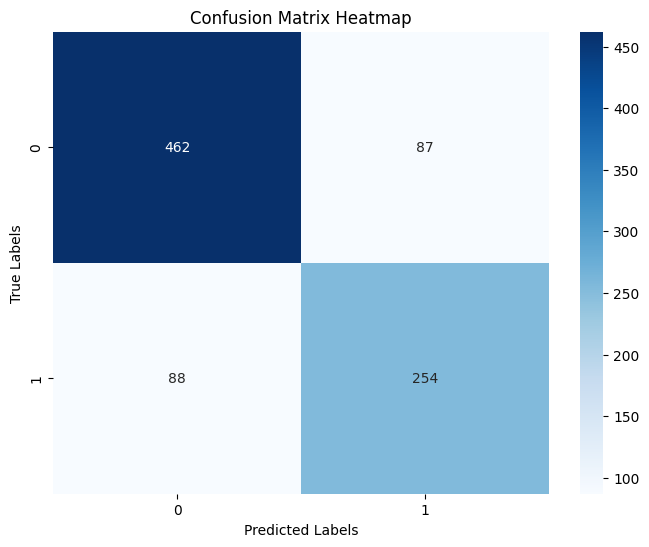

submission_rf.csv created successfully!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [9]:
# ============================================================
# 1. Prepare the Kaggle test set for Random Forest prediction
# ============================================================

test_set = pd.read_csv("/content/test.csv")

# Keep PassengerId separately because we need it later for submission.csv
passenger_ids = test_set["PassengerId"]

# Work on a copy so the original test_set stays unchanged
test_RF = test_set.copy()

# Drop columns we did not use in the final training features
test_RF = test_RF.drop(columns=["Cabin", "Ticket", "Name", "PassengerId"])

# Create the same feature used during training:
# family_size = passenger + siblings/spouses + parents/children
test_RF["family_size"] = test_RF["SibSp"] + test_RF["Parch"] + 1

# Drop SibSp and Parch because our final model uses family_size instead
test_RF = test_RF.drop(columns=["SibSp", "Parch"])

# Convert Sex from text to numeric values
test_RF["Sex"] = test_RF["Sex"].map({"male": 0, "female": 1})

# One-hot encode categorical columns.
# drop_first=True avoids keeping duplicate information.
test_RF = pd.get_dummies(
    test_RF,
    columns=["Pclass", "Embarked"],
    drop_first=True
)

# Fill missing values using values calculated from the training set.
# Important: never calculate these from the test set.
test_RF["Age"] = test_RF["Age"].fillna(age_mean)
test_RF["Fare"] = test_RF["Fare"].fillna(fare_mean)

# Make sure the test set has exactly the same columns as the training set,
# in the same order. Any missing dummy columns are filled with 0.
test_RF = test_RF.reindex(columns=X_family_only.columns, fill_value=0)

# Check that no missing values remain
print("Missing values in processed test set:")
print(test_RF.isna().sum())


# ============================================================
# 2. Evaluate Random Forest using cross-validation
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest model
classifier = RandomForestClassifier(
    n_estimators=200,   # number of decision trees in the forest
    random_state=42,     # makes results reproducible
    max_depth=5,
    min_samples_split=10,
    class_weight="balanced"

)

# 5-fold cross-validation:
# The training data is split into 5 parts.
# Each time, 4 parts are used for training and 1 part for validation.
scores = cross_val_score(classifier, X_family_only, y, cv=5)

print("Random Forest CV scores:", scores)
print("Random Forest mean score:", scores.mean())

# cross_val_predict gives out-of-fold predictions.
# This means every prediction is made by a model that did not train on that row.
y_pred_cv = cross_val_predict(classifier, X_family_only, y, cv=5)

# Confusion matrix compares true labels with predicted labels
cm = confusion_matrix(y, y_pred_cv)

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y, y_pred_cv))


# ============================================================
# 3. Compare Random Forest with Logistic Regression
# ============================================================

lr = LogisticRegression(max_iter=1000)

scores_lr = cross_val_score(lr, X_family_only, y, cv=5)

print("Logistic Regression CV scores:", scores_lr)
print("Logistic Regression mean score:", scores_lr.mean())


# ============================================================
# 4. Plot confusion matrix heatmap
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,       # show the numbers inside each square
    fmt="d",          # display numbers as integers; use ".2f" for decimals
    cmap="Blues"      # color theme of the heatmap
)

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# ============================================================
# 5. Train final Random Forest model and predict Kaggle test set
# ============================================================

# After evaluation, train on the full labeled training data
classifier.fit(X_family_only, y)

# Predict survival for the unlabeled Kaggle test set
test_predictions = classifier.predict(test_RF)

# Create submission file
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": test_predictions
})

submission.to_csv("submission_rf.csv", index=False)

print("submission_rf.csv created successfully!")
print(submission.head())